# Part 1 — Baseline: study the environment, compare PPO vs DQN, save the best model

This is the entry-point notebook. It (1) **studies and explains** `highway-env`, (2) trains **PPO** and **DQN** on the same seeds, (3) evaluates and **compares** them, (4) **picks the best** model by an explicit rule, and (5) saves the **best checkpoint + `part1_best.mp4`** to Google Drive.

Function-only `.py` modules are imported and driven from here; every parameter lives in `configs/highway.yaml`.

## 1. Setup — mount Drive, token, clone, install

In [2]:
import os, warnings, logging
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message=r'.*Gym has been unmaintained.*')
logging.getLogger('gym').setLevel(logging.ERROR)

from google.colab import drive
drive.mount('/content/drive')

TOKEN = None
try:
    from google.colab import userdata
    TOKEN = userdata.get('GITHUB_TOKEN')
except Exception:
    TOKEN = None
if not TOKEN:
    import getpass
    TOKEN = getpass.getpass('GitHub token (input hidden): ')
assert TOKEN, 'No token provided.'
os.environ['GITHUB_TOKEN'] = TOKEN
print('Token loaded (not displayed).')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Token loaded (not displayed).


In [3]:
%%bash
set -e
GH_USER=silvergjeka22
REPO=nesy-highway-driving
curl -fsSL -H "Authorization: token ${GITHUB_TOKEN}" \
  "https://raw.githubusercontent.com/${GH_USER}/${REPO}/main/bash/setup_colab.sh" \
  -o /content/setup_colab.sh
bash /content/setup_colab.sh

# Keep NumPy in the SciPy-compatible range Colab ships (no -U: do not bump the
# stock build). <2.0 breaks SciPy ("dtype size changed"); >=2.3 breaks NumPy's
# own C-API ("_blas_supports_fpe").
pip install -q "numpy>=2.0,<2.3"


==> Repo:       silvergjeka22/nesy-highway-driving (private)
==> Workdir:    /content/nesy-highway-driving
==> Drive root: /content/drive/MyDrive/nesy-highway-driving
==> Repo exists; pulling latest.
Already up to date.
==> Installing xvfb (headless rendering).
==> Installing requirements.
==> Keeping NumPy in the SciPy-compatible range (>=2.0,<2.3).
==> Creating Drive results folders.
==> Done.
    Add the repo to sys.path in Python:  import sys; sys.path.insert(0, '/content/nesy-highway-driving')
    Results will mirror to:              /content/drive/MyDrive/nesy-highway-driving


In [4]:
# --- NumPy/SciPy self-heal. Colab's SciPy is built for its stock NumPy (2.0.x);
#     a newer NumPy (>=2.3) breaks the C-API ("_blas_supports_fpe"), and an older
#     one breaks the wheels ("dtype size changed"). If the numeric stack can't
#     import, force-reinstall a compatible NumPy and restart the runtime ONCE
#     (sentinel-guarded, no loop).
import os, sys, subprocess
def _stack_ok():
    try:
        import numpy as _np
        _ = _np.random.Generator
        import scipy.special  # the import chain highway-env triggers; fails on a bad NumPy
        return True
    except Exception:
        return False
if not _stack_ok() and not os.path.exists('/content/.np_repaired'):
    open('/content/.np_repaired', 'w').close()
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--force-reinstall',
                    '--no-cache-dir', 'numpy>=2.0,<2.3'], check=False)
    print('Repaired the NumPy/SciPy stack; restarting the runtime once. '
          'After it restarts, run Runtime > Run all again.')
    sys.stdout.flush()
    os.kill(os.getpid(), 9)
# ---------------------------------------------------------------------------

import sys
sys.path.insert(0, '/content/nesy-highway-driving')
%cd /content/nesy-highway-driving
from utils import load_config, drive_path, save_json
cfg = load_config('configs/highway.yaml')

# Headless rendering so every part can save its .mp4 to Drive.
from pyvirtualdisplay import Display
_display = Display(visible=0, size=(900, 480)); _display.start()
print('virtual display started; config loaded')

/content/nesy-highway-driving
virtual display started; config loaded


## 2. Study & explain the environment

**`highway-env`** is a lightweight driving simulator with surrounding traffic. We use the **`highway-v0`** scenario with **discrete tactical meta-actions** — the agent picks a manoeuvre and a low-level controller handles steering/throttle. This is the deliberate hinge for Part 2: symbolic rules are naturally written over *manoeuvres*.

- **Action space (`DiscreteMetaAction`):** `LANE_LEFT, IDLE, LANE_RIGHT, FASTER, SLOWER`.
- **Observation (`Kinematics`):** ego + the `vehicles_count`−1 nearest vehicles as `[presence, x, y, vx, vy]`, ego-relative, normalised, fixed shape.
- **Reward:** native speed/lane-keeping − collision, **plus light shaping** (small bonus per car passed, small off-road penalty). Kept light so it does not confound the Part-2 NeSy comparison.

Below: the printed observation, a rendered frame, and a short random-policy clip so you can see the task before any learning.

observation shape: (5, 5)    (rows = ego + nearest vehicles)
features = [presence, x, y, vx, vy], ego-relative + normalised:
[[ 1.     0.895  0.     0.312  0.   ]
 [ 1.     0.112  0.75  -0.018  0.   ]
 [ 1.     0.225  0.5   -0.021  0.   ]
 [ 1.     0.327  0.75  -0.033  0.   ]
 [ 1.     0.433  0.75  -0.019  0.   ]]

action meanings: {'type': 'DiscreteMetaAction'}


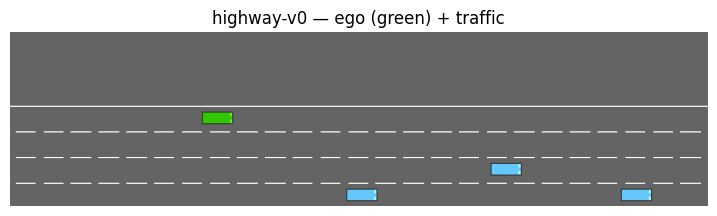

In [4]:
import matplotlib.pyplot as plt
from envs.highway_factory import make_env

env = make_env(cfg, render=True)
obs, info = env.reset(seed=cfg['seed'])
print('observation shape:', obs.shape, '   (rows = ego + nearest vehicles)')
print('features = [presence, x, y, vx, vy], ego-relative + normalised:')
print(obs.round(3))
print('\naction meanings:', cfg['env']['config']['action'])

frame = env.render()
plt.figure(figsize=(9, 3)); plt.imshow(frame); plt.axis('off')
plt.title('highway-v0 — ego (green) + traffic'); plt.show()
env.close()

In [5]:
# Random-policy rollout clip (the task before any learning).
from eval.evaluate import record_random_video
rnd = record_random_video(cfg, drive_path(cfg, 'videos', 'part1_random.mp4'), n_steps=60)
print('random rollout video saved to:', rnd)

random rollout video saved to: /content/drive/MyDrive/nesy-highway-driving/videos/part1_random.mp4


## 3. Train both baselines (same env, same seeds)

| Algorithm | Type | Why |
|---|---|---|
| **PPO** | On-policy policy-gradient | Recommended; on-policy avoids replaying stale noisy transitions; clipped objective tolerates shaping; clean credit assignment for multi-step overtakes. |
| **DQN** | Off-policy value-based | Second baseline; more sample-efficient on discrete actions but more brittle in noisy traffic. |

(This is the **RL half of Lab 5**, before any safety is added.)

In [5]:
from agents.baselines import train_ppo, train_dqn
print("PPO")
ppo_model = train_ppo(cfg)   # -> checkpoints/ppo.zip
print("DQN")
dqn_model = train_dqn(cfg)   # -> checkpoints/dqn.zip

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


PPO
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
model ready
Logging to /content/drive/MyDrive/nesy-highway-driving/metrics/curves/ppo
[PPO] training for 3000 steps on device='cpu' (printing every 200 steps)…
[PPO] step      14 | first episode done | reward 11.10 | length 13 |    5 steps/s | ETA  9.9 min
[PPO] step     200 | ep_rew_mean   12.54 | ep_len_mean   15.8 | episodes 12 |    8 steps/s | ETA  6.1 min  <- new best, saved
[PPO] step     400 | ep_rew_mean   12.68 | ep_len_mean   16.3 | episodes 24 |    8 steps/s | ETA  5.7 min  <- new best, saved
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 15.6     |
|    ep_rew_mean     | 12.2     |
| time/              |          |
|    fps             | 7        |
|    iterations      | 1        |
|    time_elapsed    | 67       |
|    total_timesteps | 512      |
---------------------------------
[PPO] step     600 | ep_rew_mean   12.08 | ep_len_mea

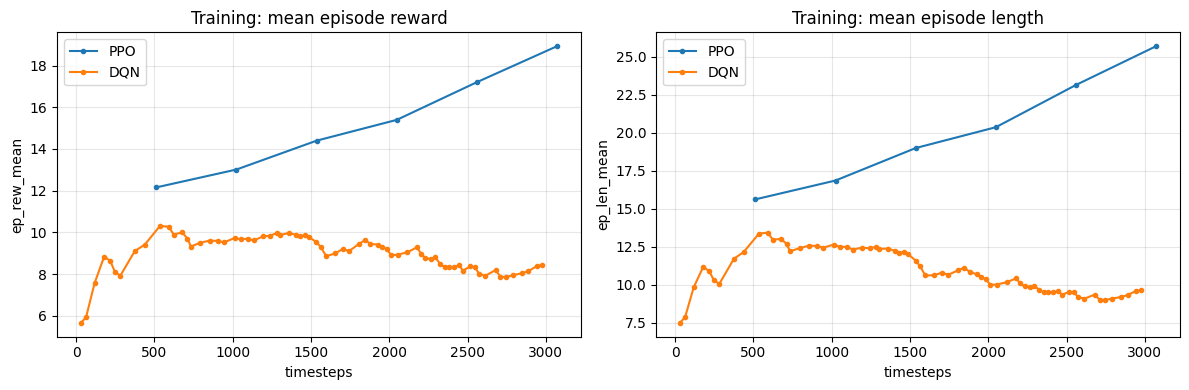

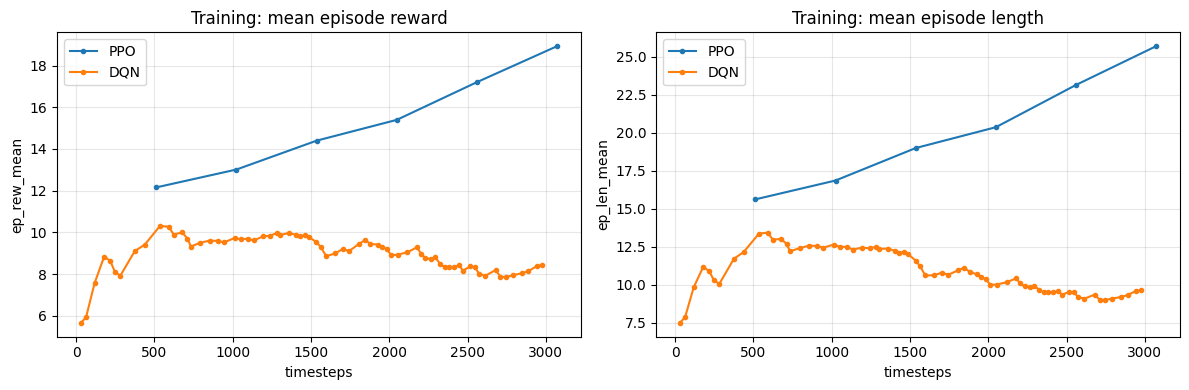

In [6]:
# --- Training curves: PPO vs DQN (logged to metrics/curves/<algo>/progress.csv) ---
from eval.plots import plot_training_curves
plot_training_curves(cfg, tags=('ppo', 'dqn'))

## 4. Evaluate both on the same held-out seeds

In [7]:
from eval.evaluate import evaluate
m_ppo = evaluate(ppo_model, cfg); save_json(m_ppo, drive_path(cfg, 'metrics', 'ppo.json'))
m_dqn = evaluate(dqn_model, cfg); save_json(m_dqn, drive_path(cfg, 'metrics', 'dqn.json'))
print('PPO:', m_ppo['summary'])
print('DQN:', m_dqn['summary'])

PPO: {'n_episodes': 50, 'crash_rate': 0.7, 'on_road_pct': {'mean': 100.0, 'std': 0.0}, 'overtakes': {'mean': 2.24, 'std': 2.396330528120026}, 'return': {'mean': 18.115754929505847, 'std': 10.40584969934049}, 'native_return': {'mean': 18.00375492950585, 'std': 10.348957957030809}, 'length': {'mean': 24.04, 'std': 14.038461454162276}}
DQN: {'n_episodes': 50, 'crash_rate': 1.0, 'on_road_pct': {'mean': 100.0, 'std': 0.0}, 'overtakes': {'mean': 2.72, 'std': 1.9187495928338332}, 'return': {'mean': 9.254366584842666, 'std': 5.312959324753539}, 'native_return': {'mean': 9.118366584842667, 'std': 5.228237676202129}, 'length': {'mean': 11.58, 'std': 6.274041759503996}}


In [8]:
import pandas as pd
def row(name, m):
    s = m['summary']
    return {'algo': name, 'crash_rate': round(s['crash_rate'], 3),
            'on_road_%': f"{s['on_road_pct']['mean']:.1f}\u00b1{s['on_road_pct']['std']:.1f}",
            'overtakes': f"{s['overtakes']['mean']:.2f}\u00b1{s['overtakes']['std']:.2f}",
            'return': f"{s['return']['mean']:.2f}\u00b1{s['return']['std']:.2f}",
            'length': f"{s['length']['mean']:.1f}\u00b1{s['length']['std']:.1f}"}
pd.DataFrame([row('PPO', m_ppo), row('DQN', m_dqn)])

,algo,crash_rate,on_road_%,overtakes,return,length
0,PPO,0.7,100.0±0.0,2.24±2.40,18.12±10.41,24.0±14.0
1,DQN,1.0,100.0±0.0,2.72±1.92,9.25±5.31,11.6±6.3


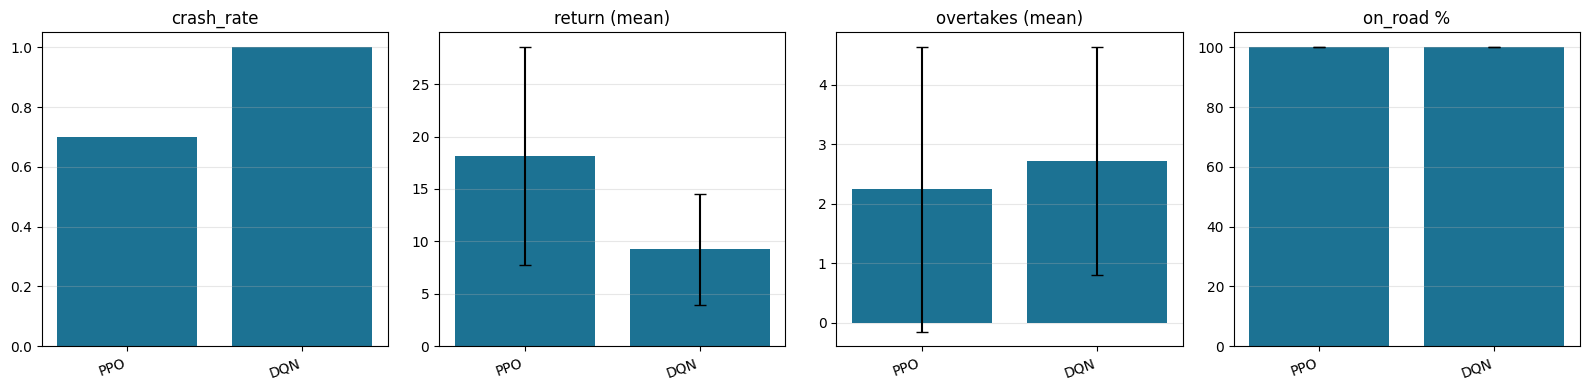

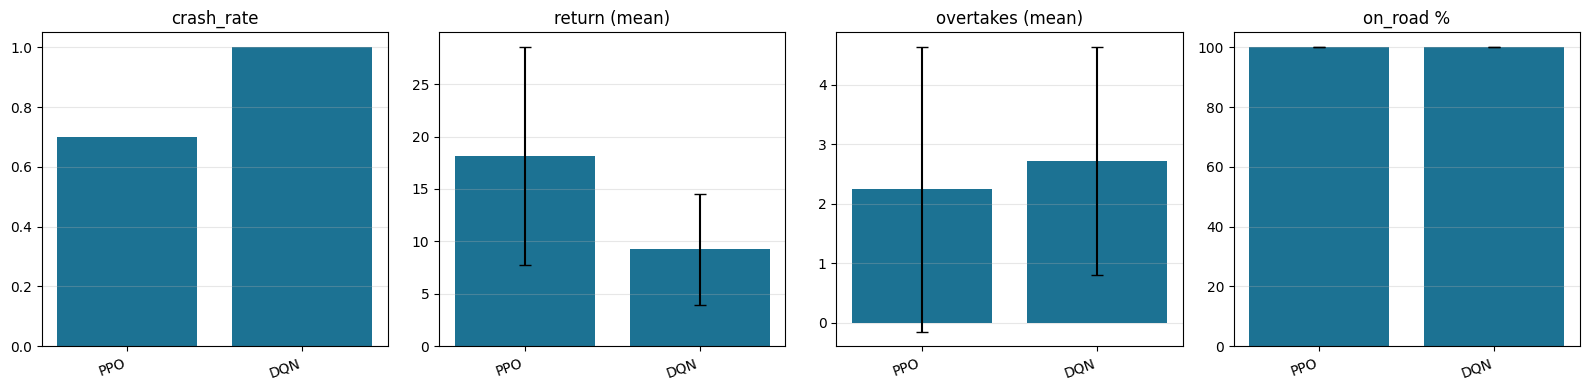

In [9]:
# --- Evaluation comparison: crash rate, return, overtakes, on-road % ---
from eval.plots import plot_eval_comparison
plot_eval_comparison({'PPO': m_ppo, 'DQN': m_dqn}, cfg, save_as='eval_compare.png')

## 5. Pick the best model + save it (and `part1_best.mp4`) to Drive
Selection rule (from `configs/highway.yaml` → `select:`): among models within `within_return_pct` of the top mean return, choose the **lowest crash rate** (safety-first). The chosen tag is recorded so Parts 2 and 4 load exactly this checkpoint.

In [ ]:
from agents.baselines import load_model
from eval.evaluate import record_video

# Load the trained baselines back from their Drive checkpoints (the .zip files
# saved during training — already the best-by-reward policy for each).
ppo_model = load_model(drive_path(cfg, 'checkpoints', 'ppo.zip'), 'ppo')
dqn_model = load_model(drive_path(cfg, 'checkpoints', 'dqn.zip'), 'dqn')

# Best model for this task = PPO (the recommended baseline). Picked directly.
tag = 'ppo'
best_model = ppo_model
print('Selected best model:', tag)

# Save the essentials FIRST (so a render hiccup can never lose them).
best_model.save(drive_path(cfg, 'checkpoints', f'part1_best_{tag}.zip'))
save_json({'tag': tag}, drive_path(cfg, 'metrics', 'part1_best.json'))
print('Saved: checkpoints/part1_best_%s.zip + metrics/part1_best.json' % tag)

# Video is a nice-to-have; never let it abort Part 1.
try:
    video = record_video(best_model, cfg, drive_path(cfg, 'videos', 'part1_best.mp4'))
    print('Saved video:', video)
except Exception as e:
    print('Video skipped (rendering issue):', repr(e))

**Exit criterion.** Best checkpoint on Drive (`part1_best_{tag}.zip`), the PPO-vs-DQN table, a documented selection rule, and **`part1_best.mp4`**. Next: `colab_2_nesy.ipynb` loads exactly this checkpoint.